Dataset Understanding & SQLite Basics

In [43]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
conn = sqlite3.connect(
    "database.sqlite"
)

In [45]:
query = """
SELECT name FROM sqlite_master WHERE type='table';
"""

tables = pd.read_sql(
    query,
    conn
)

tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


In [46]:
print(
    "Total Tables:",
    len(tables)
)

Total Tables: 8


In [47]:
pd.read_sql(
    "SELECT * FROM Team LIMIT 5",
    conn
)

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673,KRC Genk,GEN
1,2,9993,675,Beerschot AC,BAC
2,3,10000,15005,SV Zulte-Waregem,ZUL
3,4,9994,2007,Sporting Lokeren,LOK
4,5,9984,1750,KSV Cercle Brugge,CEB


In [48]:
pd.read_sql(
    "SELECT * FROM Player LIMIT 5",
    conn
)

,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight
0,1,505942,Aaron Appindangoye,218353,1992-02-29 00:00:00,182.88,187
1,2,155782,Aaron Cresswell,189615,1989-12-15 00:00:00,170.18,146
2,3,162549,Aaron Doran,186170,1991-05-13 00:00:00,170.18,163
3,4,30572,Aaron Galindo,140161,1982-05-08 00:00:00,182.88,198
4,5,23780,Aaron Hughes,17725,1979-11-08 00:00:00,182.88,154


In [49]:
pd.read_sql(
    "SELECT * FROM Match LIMIT 5",
    conn
)

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [50]:
pd.read_sql(
    "SELECT * FROM League LIMIT 10",
    conn
)

,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A
5,13274,13274,Netherlands Eredivisie
6,15722,15722,Poland Ekstraklasa
7,17642,17642,Portugal Liga ZON Sagres
8,19694,19694,Scotland Premier League
9,21518,21518,Spain LIGA BBVA


In [51]:
team = pd.read_sql(
    "SELECT * FROM Team",
    conn
)

match = pd.read_sql(
    "SELECT * FROM Match",
    conn
)

player = pd.read_sql(
    "SELECT * FROM Player",
    conn
)

league = pd.read_sql(
    "SELECT * FROM League",
    conn
)

In [52]:
print(team.shape)
print(match.shape)
print(player.shape)
print(league.shape)

(299, 5)
(25979, 115)
(11060, 7)
(11, 3)


In [53]:
print(team.columns)
print(match.columns)
print(player.columns)
print(league.columns)

Index(['id', 'team_api_id', 'team_fifa_api_id', 'team_long_name',
       'team_short_name'],
      dtype='object')
Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='object', length=115)
Index(['id', 'player_api_id', 'player_name', 'player_fifa_api_id', 'birthday',
       'height', 'weight'],
      dtype='object')
Index(['id', 'country_id', 'name'], dtype='object')


In [54]:
match.isnull().sum().sort_values(
    ascending=False
).head(20)

PSD           14811
PSA           14811
PSH           14811
BSH           11818
BSA           11818
BSD           11818
GBD           11817
GBH           11817
GBA           11817
card          11762
shoton        11762
goal          11762
corner        11762
shotoff       11762
foulcommit    11762
cross         11762
possession    11762
SJA            8882
SJH            8882
SJD            8882
dtype: int64

Exploratory Data Analysis

In [55]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("database.sqlite")

match = pd.read_sql(
    "SELECT * FROM Match",
    conn
)

team = pd.read_sql(
    "SELECT * FROM Team",
    conn
)

league = pd.read_sql(
    "SELECT * FROM League",
    conn
)

In [56]:
match.shape

(25979, 115)

In [57]:
match.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [58]:
match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 115 entries, id to BSA
dtypes: float64(96), int64(9), object(10)
memory usage: 22.8+ MB


In [59]:
league_matches = match.merge(
    league,
    left_on='league_id',
    right_on='id'
)

In [60]:
league_matches['name'].value_counts()

name
England Premier League      3040
France Ligue 1              3040
Spain LIGA BBVA             3040
Italy Serie A               3017
Netherlands Eredivisie      2448
Germany 1. Bundesliga       2448
Portugal Liga ZON Sagres    2052
Poland Ekstraklasa          1920
Scotland Premier League     1824
Belgium Jupiler League      1728
Switzerland Super League    1422
Name: count, dtype: int64

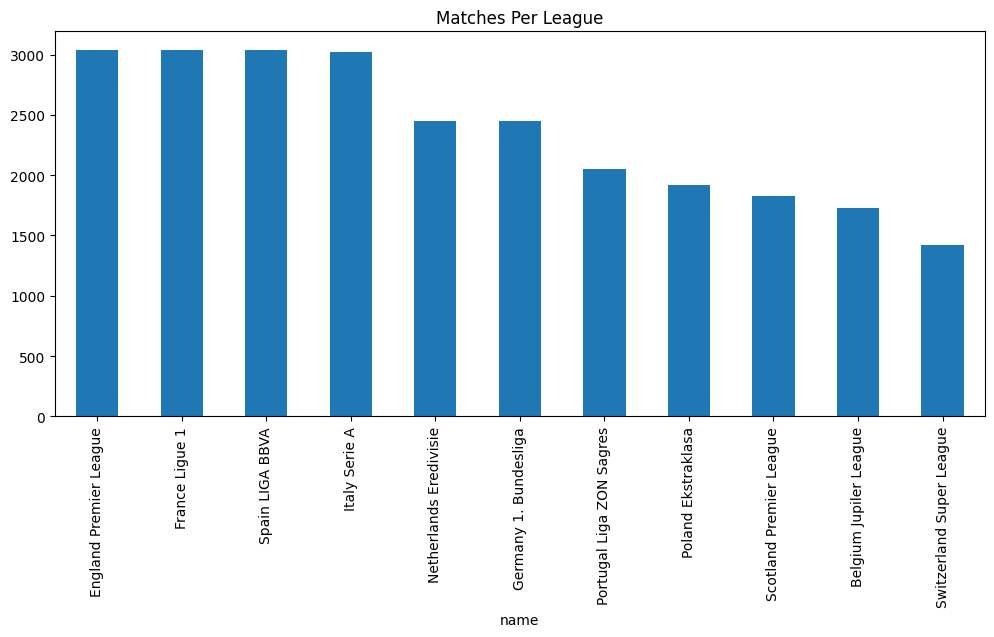

In [61]:
league_matches['name'].value_counts().plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Matches Per League")
plt.show()

In [62]:
match['home_team_goal'].describe()

count    25979.000000
mean         1.544594
std          1.297158
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: home_team_goal, dtype: float64

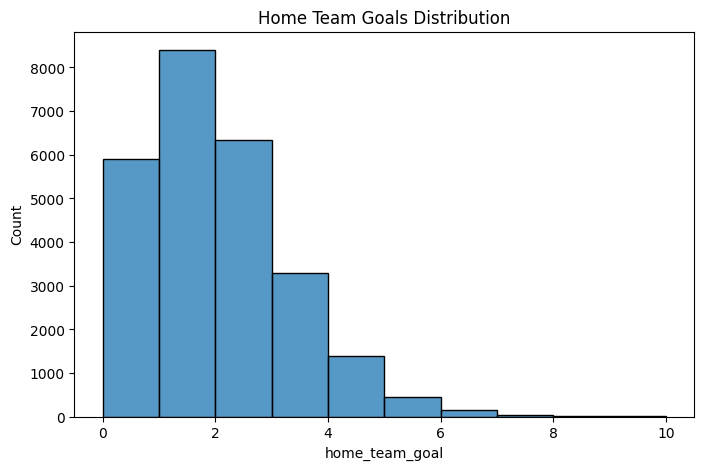

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    match['home_team_goal'],
    bins=10
)

plt.title("Home Team Goals Distribution")
plt.show()

In [64]:
match['away_team_goal'].describe()

count    25979.000000
mean         1.160938
std          1.142110
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: away_team_goal, dtype: float64

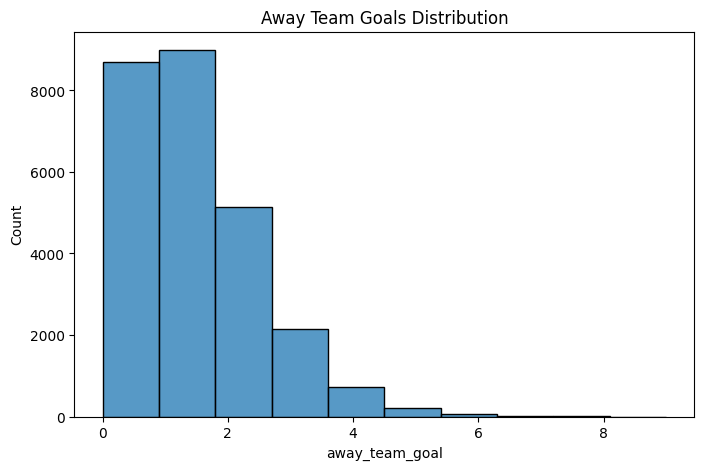

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    match['away_team_goal'],
    bins=10
)

plt.title("Away Team Goals Distribution")
plt.show()

In [33]:
home_wins = (
    match['home_team_goal']
    >
    match['away_team_goal']
).sum()

home_wins

np.int64(11917)

In [34]:
away_wins = (
    match['away_team_goal']
    >
    match['home_team_goal']
).sum()

away_wins

np.int64(7466)

In [35]:
draws = (
    match['home_team_goal']
    ==
    match['away_team_goal']
).sum()

draws

np.int64(6596)

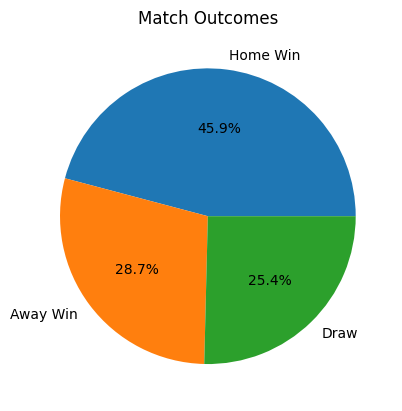

In [36]:
results = pd.Series({
    'Home Win': home_wins,
    'Away Win': away_wins,
    'Draw': draws
})

results.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Match Outcomes")
plt.show()

In [37]:
match['total_goals'] = (
    match['home_team_goal']
    +
    match['away_team_goal']
)

In [38]:
match.sort_values(
    'total_goals',
    ascending=False
)[
    [
        'date',
        'home_team_goal',
        'away_team_goal',
        'total_goals'
    ]
].head(10)

,date,home_team_goal,away_team_goal,total_goals
20106,2010-05-05 00:00:00,6,6,12
24247,2015-12-20 00:00:00,10,2,12
9210,2013-03-30 00:00:00,9,2,11
3092,2011-08-28 00:00:00,8,2,10
3565,2013-05-19 00:00:00,5,5,10
5191,2009-11-08 00:00:00,5,5,10
3368,2012-12-29 00:00:00,7,3,10
14223,2011-11-06 00:00:00,6,4,10
13898,2010-10-24 00:00:00,10,0,10
24122,2014-09-20 00:00:00,2,8,10


In [39]:
match.isnull().sum().sort_values(
    ascending=False
).head(20)

PSD           14811
PSA           14811
PSH           14811
BSA           11818
BSH           11818
BSD           11818
GBH           11817
GBA           11817
GBD           11817
goal          11762
cross         11762
shotoff       11762
shoton        11762
foulcommit    11762
card          11762
corner        11762
possession    11762
SJA            8882
SJD            8882
SJH            8882
dtype: int64

Football Data Cleaning & ML Dataset Preparation

In [66]:
football_df = match.copy()

In [67]:
football_df.shape

(25979, 115)

In [68]:
football_df = football_df[
    [
        'season',
        'league_id',
        'home_team_api_id',
        'away_team_api_id',
        'home_team_goal',
        'away_team_goal'
    ]
]

In [69]:
football_df.head()

,season,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,1,9987,9993,1,1
1,2008/2009,1,10000,9994,0,0
2,2008/2009,1,9984,8635,0,3
3,2008/2009,1,9991,9998,5,0
4,2008/2009,1,7947,9985,1,3


In [70]:
football_df.isnull().sum()

season              0
league_id           0
home_team_api_id    0
away_team_api_id    0
home_team_goal      0
away_team_goal      0
dtype: int64

In [71]:
football_df = football_df.dropna()

In [72]:
football_df['result'] = football_df.apply(
    lambda row:
        'Home Win'
        if row['home_team_goal'] > row['away_team_goal']
        else (
            'Away Win'
            if row['home_team_goal'] < row['away_team_goal']
            else 'Draw'
        ),
    axis=1
)

In [73]:
football_df['result'].value_counts()

result
Home Win    11917
Away Win     7466
Draw         6596
Name: count, dtype: int64

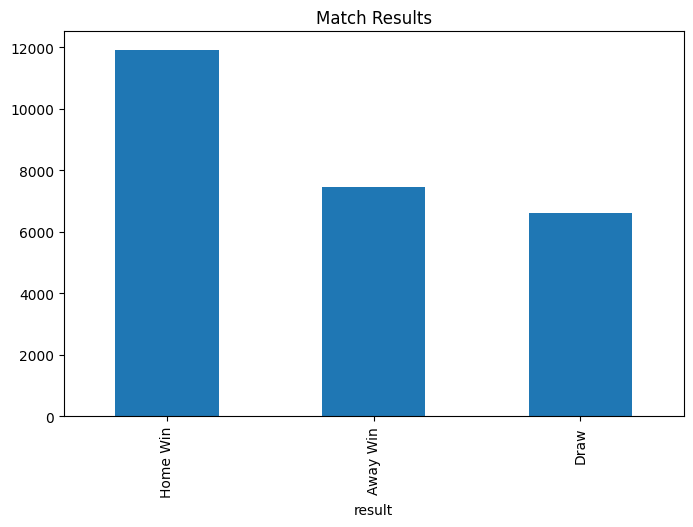

In [74]:
football_df['result'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Match Results")
plt.show()

In [75]:
football_df = football_df.drop(
    [
        'home_team_goal',
        'away_team_goal'
    ],
    axis=1
)

In [76]:
football_df.head()

,season,league_id,home_team_api_id,away_team_api_id,result
0,2008/2009,1,9987,9993,Draw
1,2008/2009,1,10000,9994,Draw
2,2008/2009,1,9984,8635,Away Win
3,2008/2009,1,9991,9998,Home Win
4,2008/2009,1,7947,9985,Away Win


In [77]:
football_df['home_team_api_id'].nunique()

299

In [78]:
football_df['away_team_api_id'].nunique()

299

In [79]:
league = pd.read_sql(
    "SELECT * FROM League",
    conn
)

In [80]:
football_df = football_df.merge(
    league[['id','name']],
    left_on='league_id',
    right_on='id',
    how='left'
)

In [81]:
football_df.rename(
    columns={'name':'league_name'},
    inplace=True
)

In [82]:
football_df['league_name'].value_counts()

league_name
England Premier League      3040
France Ligue 1              3040
Spain LIGA BBVA             3040
Italy Serie A               3017
Netherlands Eredivisie      2448
Germany 1. Bundesliga       2448
Portugal Liga ZON Sagres    2052
Poland Ekstraklasa          1920
Scotland Premier League     1824
Belgium Jupiler League      1728
Switzerland Super League    1422
Name: count, dtype: int64

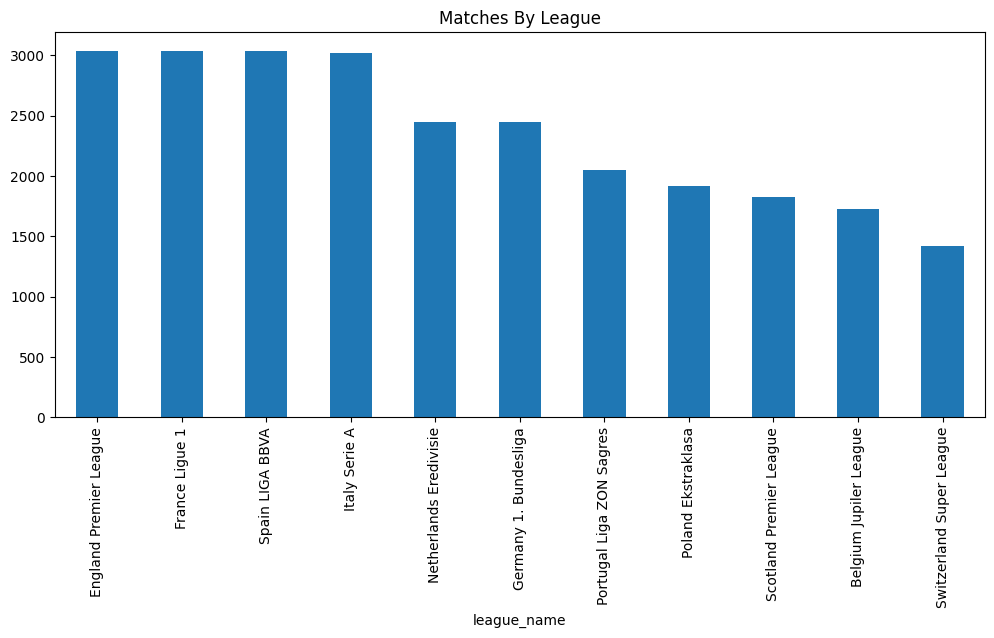

In [83]:
football_df['league_name'].value_counts().plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Matches By League")
plt.show()

In [84]:
football_ml = football_df[
    [
        'season',
        'league_name',
        'home_team_api_id',
        'away_team_api_id',
        'result'
    ]
]

In [85]:
football_ml.head()

,season,league_name,home_team_api_id,away_team_api_id,result
0,2008/2009,Belgium Jupiler League,9987,9993,Draw
1,2008/2009,Belgium Jupiler League,10000,9994,Draw
2,2008/2009,Belgium Jupiler League,9984,8635,Away Win
3,2008/2009,Belgium Jupiler League,9991,9998,Home Win
4,2008/2009,Belgium Jupiler League,7947,9985,Away Win


In [86]:
football_ml.to_csv(
    "football_ml_dataset.csv",
    index=False
)

In [87]:
football_ml = pd.read_csv(
    "football_ml_dataset.csv"
)

In [88]:
football_ml.head()

,season,league_name,home_team_api_id,away_team_api_id,result
0,2008/2009,Belgium Jupiler League,9987,9993,Draw
1,2008/2009,Belgium Jupiler League,10000,9994,Draw
2,2008/2009,Belgium Jupiler League,9984,8635,Away Win
3,2008/2009,Belgium Jupiler League,9991,9998,Home Win
4,2008/2009,Belgium Jupiler League,7947,9985,Away Win


In [89]:
X = football_ml.drop(
    'result',
    axis=1
)

y = football_ml['result']

In [90]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [92]:
for col in X.columns:
    X[col] = encoder.fit_transform(
        X[col]
    )
y = encoder.fit_transform(y)
X.head()

,season,league_name,home_team_api_id,away_team_api_id
0,0,0,244,247
1,0,0,253,248
2,0,0,241,142
3,0,0,246,251
4,0,0,34,242


In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(20783, 4)
(5196, 4)


In [94]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

In [95]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression:",
    lr_acc
)

Logistic Regression: 0.4636258660508083


In [96]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree:",
    dt_acc
)

Decision Tree: 0.4107005388760585


In [97]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest:",
    rf_acc
)

Random Forest: 0.4413010007698229


In [98]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.463626
1,Decision Tree,0.410701
2,Random Forest,0.441301


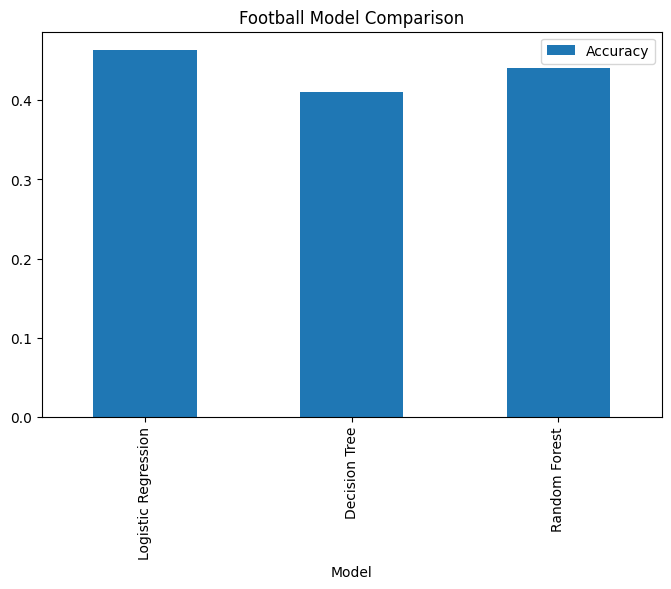

In [99]:
results.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Football Model Comparison"
)

plt.show()

In [100]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [101]:
feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
2,home_team_api_id,0.376687
3,away_team_api_id,0.365644
0,season,0.214076
1,league_name,0.043593


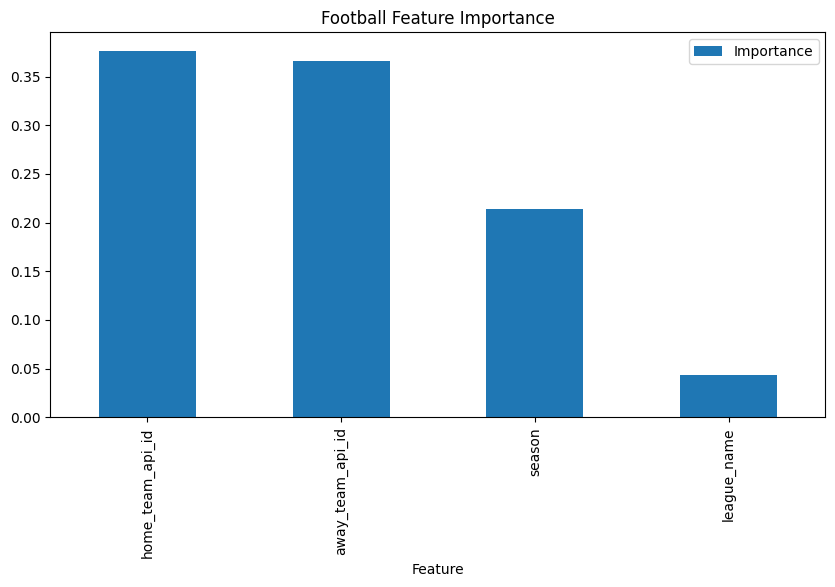

In [102]:
feature_importance.sort_values(
    by='Importance',
    ascending=False
).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Football Feature Importance"
)

plt.show()

In [103]:
sample = X_test.iloc[[0]]

prediction = rf.predict(
    sample
)

print(prediction)

[0]


Football Model Evaluation

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [105]:
best_model = rf

y_pred = best_model.predict(
    X_test
)

In [106]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.4413010007698229


In [107]:
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print(
    "Precision:",
    precision
)

Precision: 0.4282463713030468


In [108]:
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print(
    "Recall:",
    recall
)

Recall: 0.4413010007698229


In [109]:
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(
    "F1 Score:",
    f1
)

F1 Score: 0.4333024384331254


In [110]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 544  341  585]
 [ 348  296  673]
 [ 472  484 1453]]


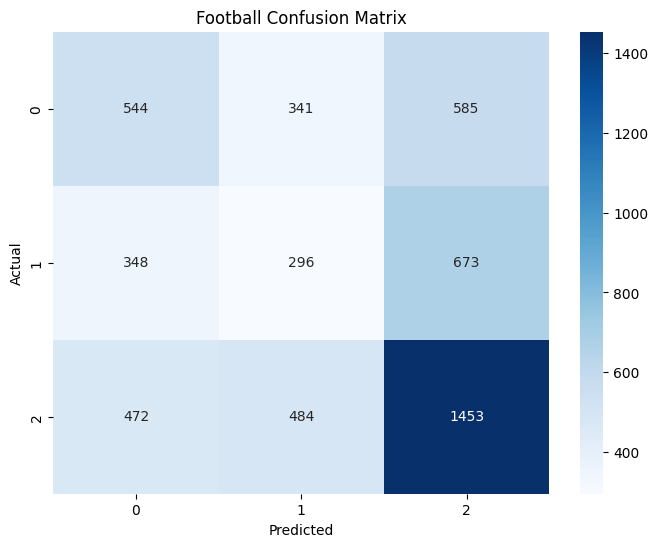

In [111]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Football Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

Football Project Completion

In [112]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.463626
2,Random Forest,0.441301
1,Decision Tree,0.410701


In [113]:
best_model = rf

In [114]:
def predict_result(sample):

    prediction = rf.predict(sample)

    return prediction

In [115]:
sample = X_test.iloc[[0]]

predict_result(sample)

array([0])